# Nigerian Ministry of Education - Student Performance Analysis

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 1: Load and Inspect the Data

In [92]:
df = pd.read_csv("../data/students.csv")

print("Dataset shape:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3))
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (2400, 38)

First 3 rows:
        student_id first_name middle_name last_name gender date_of_birth  \
0  ALA-20240729001     Obinna         NaN    Okafor      M    2010-06-15   
1  ALA-20240712002    Kelechi       Bello      Musa      M    2008-01-20   
2  ALA-20240809003   Temitope         NaN     Nwosu      M    2010-02-22   

  admission_date  class_level study_group  attendance  ...  Chemistry  \
0     2024-07-29           10     Science        90.1  ...      100.0   
1     2024-07-12           10        Arts        92.1  ...        NaN   
2     2024-08-09           10     Science        91.1  ...       21.0   

   Further Mathematics Civic Education Computer Science Hausa  \
0                 79.0             NaN             11.0   NaN   
1                  NaN           100.0              NaN  58.0   
2                100.0             NaN             34.0   NaN   

   English Language Government Mathematics Yoruba Literature in English  
0               100       

### Step 2: Data Cleaning and Preparation

In [93]:
class_level_map = {
    10: "SS1",
    11: "SS2",
    12: "SS3"
}

df["class_level"] = df["class_level"].replace(class_level_map)

df.rename(
    columns={
        "Further Mathematics": "further_mathematics",
        "Civic Education": "civic_education",
        "Computer Science": "computer_science",
        "English Language": "english_language",
        "Literature in English": "literature_in_english",
        "Mathematics": "mathematics",
        "Biology": "biology",
        "Physics": "physics",
        "Agriculture": "agriculture",
        "Geography": "geography",
        "French": "french",
        "History": "history",
        "Hausa": "hausa",
        "Igbo": "igbo",
        "Chemistry": "chemistry",
        "Economics": "economics",
        "Government": "government",
        "Yoruba": "yoruba",
    },
    inplace=True,
)

# Define a preferred order for income levels (low -> high)
income_order = ["Low", "Lower Middle", "Upper Middle", "High"]

# Convert data in family_income_level column to an order Categorical so plots sort correctly
df["family_income_level"] = pd.Categorical(df["family_income_level"], categories=income_order, ordered=True)

# Define the correct order for study hours (low -> high)
study_hours_order = ["0-1 Hour", "1-2 Hours", "2-3 Hours", "More than 3 hours"]

df["daily_study_hours"] = pd.Categorical(df["daily_study_hours"], categories=study_hours_order, ordered=True)

# print("\nIncome level value counts:")
# print(df["family_income_level"].value_counts())
#
# print("")
#
# print("\nDaily study hours value counts:")
# print(df["daily_study_hours"].value_counts())

### Task 1: Violin Plots

Mathematics and English Language scores by family income level

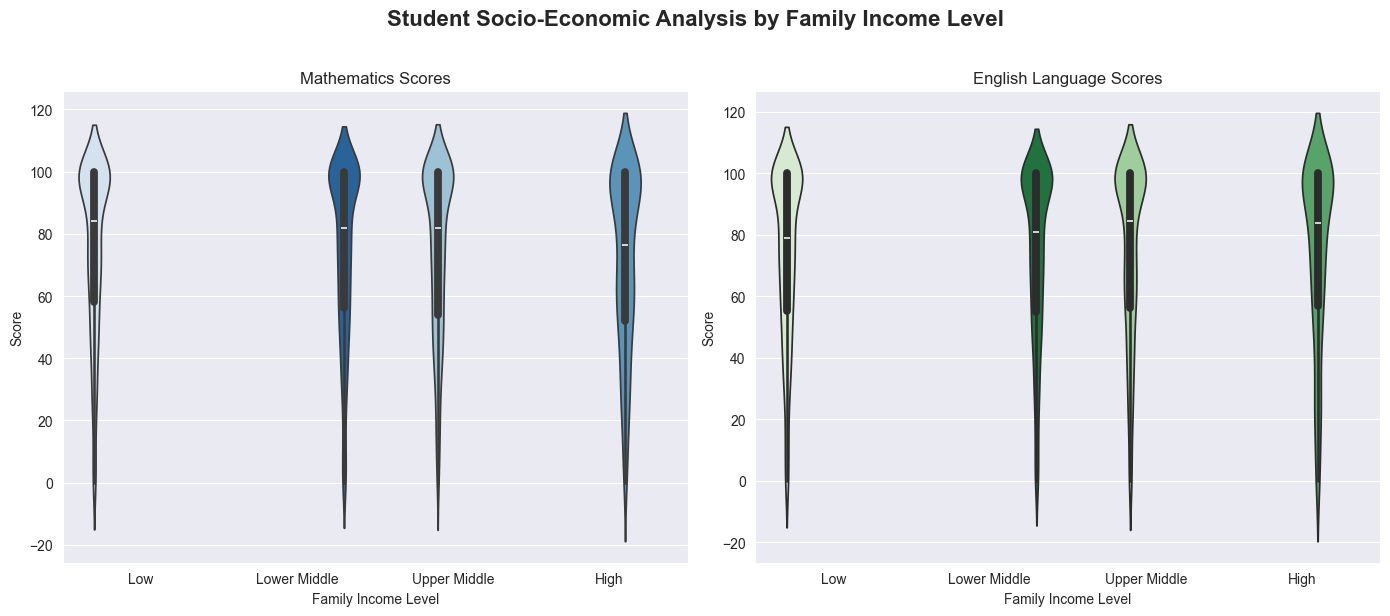

In [94]:
# Drop rows where Maths or English score is missing
violin_df = df.dropna(subset=["mathematics", "english_language"])

# Create a figure with two (2) subplots (violin plots, side-by-sde)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
fig.suptitle("Student Socio-Economic Analysis by Family Income Level", fontsize=16, fontweight="bold", y=1.02)

# Left plot: Mathematics
sns.violinplot(
    data=violin_df,
    x="family_income_level",
    y="mathematics",
    ax=axes[0],
    hue="family_income_level",
    order=income_order,
    legend=False,
    palette="Blues",
    inner="box",
)

axes[0].set_title("Mathematics Scores")
axes[0].set_xlabel("Family Income Level")
axes[0].set_ylabel("Score")
# axes[0].tick_params(axis="x", rotation=15)


# Right plot: English Language
sns.violinplot(
    data=violin_df,
    x="family_income_level",
    y="english_language",
    ax=axes[1],
    hue="family_income_level",
    order=income_order,
    legend=False,
    palette="Greens",
    inner="box",
)

axes[1].set_title("English Language Scores")
axes[1].set_xlabel("Family Income Level")
axes[1].set_ylabel("Score")
# axes[0].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("students_socioeconomic_analysis_violinplot.png", dpi=300, bbox_inches="tight")
plt.show()

### Task 2: Pair Plot

Relationships between core subject scores colored by gender

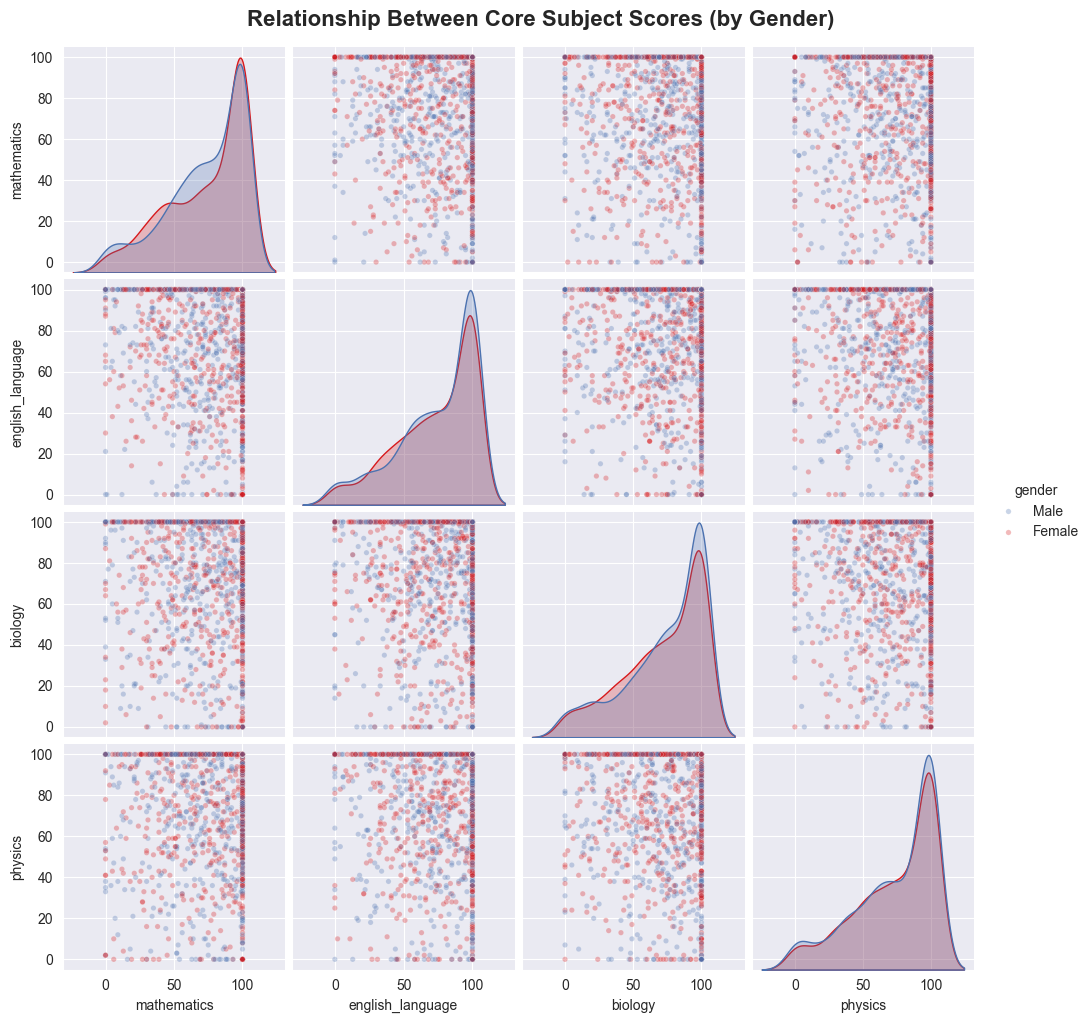

In [95]:
core_subjects = ["mathematics", "english_language", "biology", "physics"]
all_columns = core_subjects + ["gender"]

pair_df = df.dropna(subset=all_columns)

# Map gender codes to readable labels
pair_df = pair_df.copy()
pair_df["gender"] = pair_df["gender"].map({
    "M": "Male",
    "F": "Female",
})

# Build the pair plot
pair_plot = sns.pairplot(
    pair_df[all_columns],
    hue="gender",
    palette={ "Male": "#4c72b0", "Female": "#d7191c" },
    plot_kws={"alpha": 0.3, "s": 15},
    diag_kind="kde",
)

pair_plot.fig.suptitle("Relationship Between Core Subject Scores (by Gender)", fontsize=16, fontweight="bold", y=1.02)
pair_plot.savefig("pairplot.png", dpi=300, bbox_inches="tight")
plt.show()

### Task 3

Correlation Heat Map

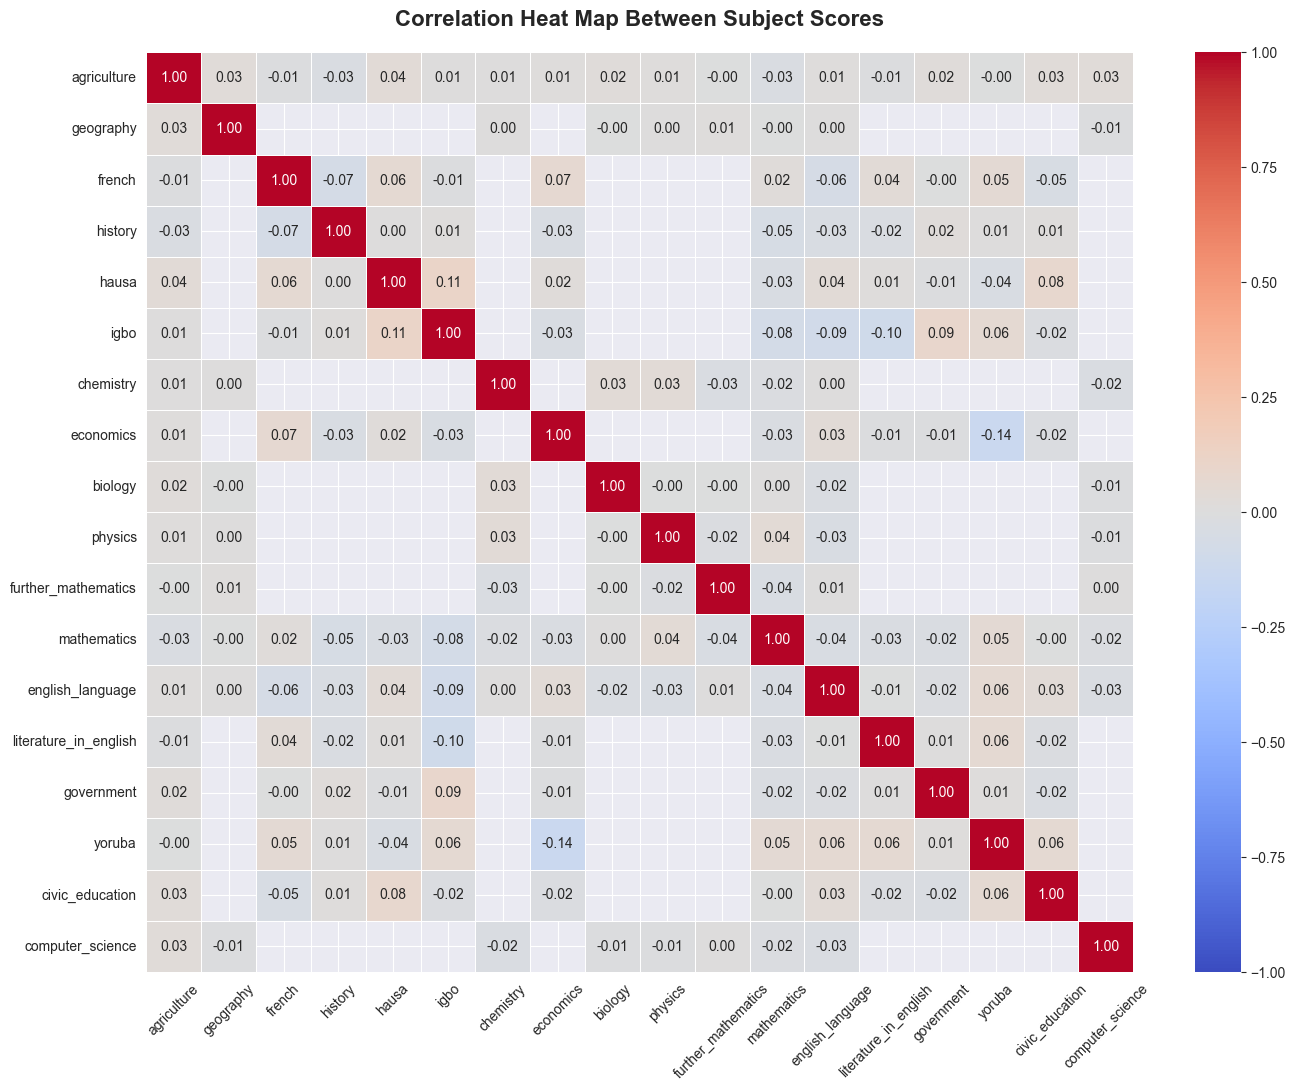

In [96]:
# Select all subject score colums
subject_columns = [
    "agriculture", "geography", "french", "history", "hausa", "igbo", "chemistry", "economics", "biology",
    "physics", "further_mathematics", "mathematics", "english_language", "literature_in_english",
    "government", "yoruba", "civic_education", "computer_science"
]

# Compute the correlation matrix (ignores NaN automatically)
corr_matrix = df[subject_columns].corr()

# Plot the heatmap
fig, axes = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    ax=axes,
)

axes.set_title("Correlation Heat Map Between Subject Scores", fontsize=16, fontweight="bold", y=1.02)
axes.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("corr_heatmap_subject_scores.png", dpi=300, bbox_inches="tight")
plt.show()

### Task 4

Bar Plots - Students performance analysis based on Three (3) Factor

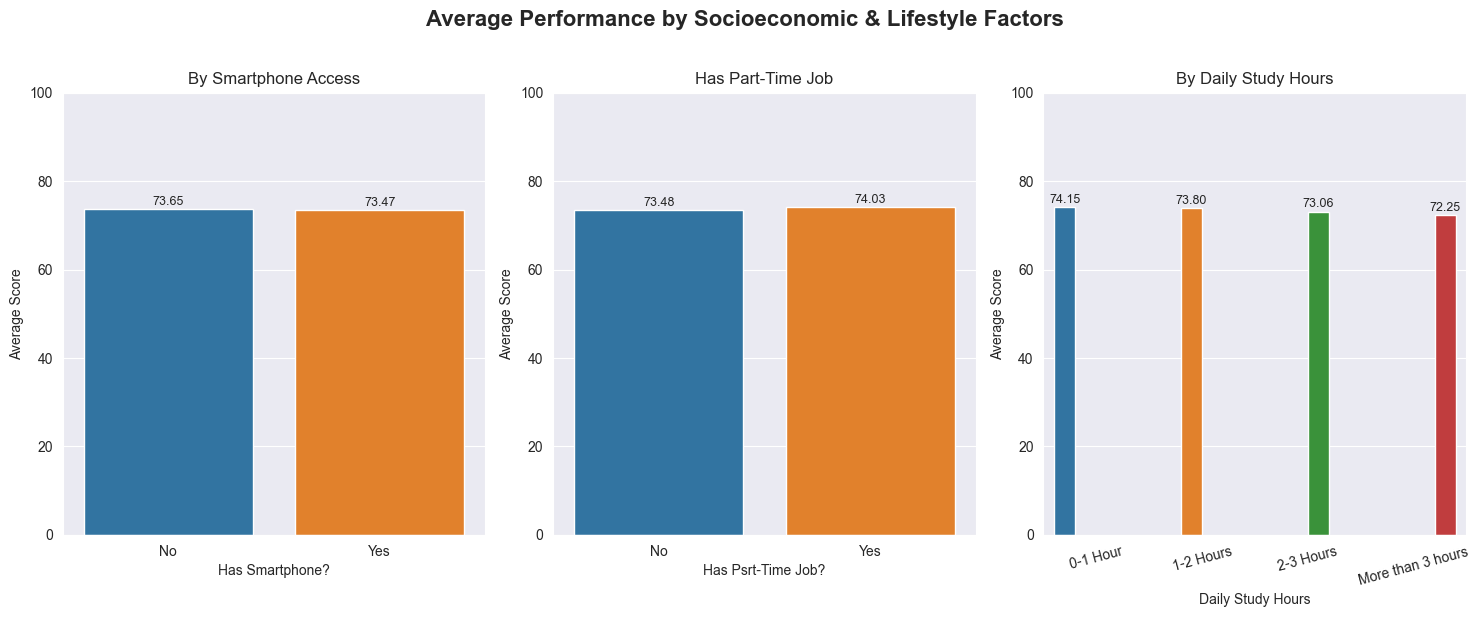

In [109]:
# Make a bar plot showing performance differences based on:
#     - Whether students have a smartphone
#     - Whether students have a part-time job
#     - Daily study hours category

df["average_score"] = df[subject_columns].mean(axis=1)

# 4a - Smatphone access
smartphone_avg = (df.dropna(subset=["average_score", "smartphone"])
                        .groupby("smartphone")["average_score"]
                        .mean()
                        .reset_index()
)

# 4b - Has job
has_job_avg = (
    df.dropna(subset=["average_score", "has_job"])
            .groupby("has_job")["average_score"]
            .mean()
            .reset_index()
)

# 4c - Daily Study Hours
daily_study_avg = (
    df.dropna(subset=["average_score", "daily_study_hours"])
            .groupby("daily_study_hours", observed=True)["average_score"]
            .mean()
            .reset_index()
)

# Build a figure with three bar plots side by side
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))
fig.suptitle("Average Performance by Socioeconomic & Lifestyle Factors", fontsize=16, fontweight="bold", y=1.02)

def add_bar_label(ax: plt.Axes):
    for bar in ax.patches:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.3,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

# Smartphone bar chart
sns.barplot(
    data=smartphone_avg,
    x="smartphone",
    y="average_score",
    hue="smartphone",
    legend=False,
    ax=axes[0],
)

axes[0].set_title("By Smartphone Access")
axes[0].set_xlabel("Has Smartphone?")
axes[0].set_ylabel("Average Score")
axes[0].set_ylim(0, 100)
add_bar_label(axes[0])


# "Has Job" bar chart
sns.barplot(
    data=has_job_avg,
    x="has_job",
    y="average_score",
    hue="has_job",
    legend=False,
    ax=axes[1],
)

axes[1].set_title("Has Part-Time Job")
axes[1].set_xlabel("Has Part-Time Job?")
axes[1].set_ylabel("Average Score")
axes[1].set_ylim(0, 100)
add_bar_label(axes[1])

# "Daily Study Hours" bar chart
sns.barplot(
    data=daily_study_avg,
    x="daily_study_hours",
    y="average_score",
    hue="daily_study_hours",
    legend=False,
    ax=axes[2],
    order=study_hours_order,
)

axes[2].set_title("By Daily Study Hours")
axes[2].set_xlabel("Daily Study Hours")
axes[2].set_ylabel("Average Score")
axes[2].set_ylim(0, 100)
axes[2].tick_params(axis="x", rotation=15)
add_bar_label(axes[2])

plt.tight_layout()
plt.savefig("avg_performance.png", dpi=300, bbox_inches="tight")
plt.show()